In [86]:
from cytograph import Algorithm, creates, requires, div0
from cytograph.visualization.scatter import scatterc, scattern
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from typing import List
import shoji
import cytograph as cg
import cytograph.visualization as cgplot
import collections
from typing import List, Optional
import matplotlib.patheffects as PathEffects
import fastcluster
import igraph
import leidenalg as la
import scipy.cluster.hierarchy as hc
from hmmlearn import hmm
from openTSNE import TSNE
from pynndescent import NNDescent
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA
from tqdm import trange
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from cytograph.visualization import Colorizer
from matplotlib.lines import Line2D
import scipy as sci
import loompy
import scanpy as sc
from scipy.stats import ks_2samp, mannwhitneyu, ttest_ind

In [91]:
GBO.write_h5ad('/proj/cytograph/jesper/GBM_revision/bulk_samples_GBO_control_smartseq_2025')

In [13]:
GBO

AnnData object with n_obs × n_vars = 16 × 63757
    obs: 'Barcode', 'BarcodeIdx', 'Celltype', 'Condition', 'ID', 'Pool', 'Sample', 'Time', 'Time_Sample', 'TotalMTCounts', 'TotalReadGenes', 'TotalReads', 'TotalUMIGenes', 'TotalUMIs', 'obs_names'
    var: 'Accession', 'Chromosome'
    layers: 'Exon'

In [14]:
GBO.obs.index = [x for x in GBO.obs.obs_names]

In [87]:
GBO = sc.read_loom('/proj/cytograph/jesper/GBM_revision/GBO_control_smartseq_2025.loom')

In [15]:
GBO.obs

,Barcode,BarcodeIdx,Celltype,Condition,ID,Pool,Sample,Time,Time_Sample,TotalMTCounts,TotalReadGenes,TotalReads,TotalUMIGenes,TotalUMIs,obs_names
A01,-,0,GBO,-P-H,A01,20250915,SL007,0h,0h_SL007,736052,20750,19129730,20750,19129730,A01
A10,-,1,GBO,-P-H,A10,20250915,SL013,72h,72h_SL013,1064583,21520,19263749,21520,19263749,A10
A11,-,2,GBO,-P-H,A11,20250915,SL014,72h,72h_SL014,544076,19977,16495182,19977,16495182,A11
A12,-,3,GBO,-P-H,A12,20250915,SL027A,72h,72h_SL027A,495789,20620,17580279,20620,17580279,A12
A02,-,4,GBO,-P-H,A02,20250915,SL013,0h,0h_SL013,911511,20911,16290418,20911,16290418,A02
A03,-,5,GBO,-P-H,A03,20250915,SL014,0h,0h_SL014,471872,19995,15414781,19995,15414781,A03
A04,-,6,GBO,-P-H,A04,20250915,SL027A,0h,0h_SL027A,730808,21165,18691567,21165,18691567,A04
A05,-,7,GBO,-P-H,A05,20250915,SL007,24h,24h_SL007,662777,21013,16066657,21013,16066657,A05
A06,-,8,GBO,-P-H,A06,20250915,SL013,24h,24h_SL013,597284,21703,17245946,21703,17245946,A06
A07,-,9,GBO,-P-H,A07,20250915,SL014,24h,24h_SL014,480989,21013,17962416,21013,17962416,A07


In [16]:
MES1 = np.array(["CHI3L1","ANXA2","ANXA1","CD44","VIM","MT2A","C1S","NAMPT","EFEMP1","C1R","SOD2","IFITM3","TIMP1","SPP1","A2M","S100A11","MT1X","S100A10","FN1","LGALS1","S100A16","CLIC1","MGST1","RCAN1","TAGLN2","NPC2","SERPING1","TCIM","EMP1","APOE","CTSB","C3","LGALS3","MT1E","EMP3","SERPINA3","ACTN1","PRDX6","IGFBP7","SERPINE1","PLP2","MGP","CLIC4","GFPT2","GSN","NNMT","TUBA1C","GJA1","TNFRSF1A","WWTR1"])
MES2 = np.array(["HILPDA","ADM","DDIT3","NDRG1","HERPUD1","DNAJB9","TRIB3","ENO2","AKAP12","SQSTM1","MT1X","ATF3","NAMPT","NRN1","SLC2A1","BNIP3","LGALS3","INSIG2","IGFBP3","PPP1R15A","VIM","PLOD2","GBE1","SLC2A3","FTL","WARS1","ERO1A","XPOT","HSPA5","GDF15","ANXA2","EPAS1","LDHA","P4HA1","SERTAD1","PFKP","PGK1","EGLN3","SLC6A6","CA9","BNIP3L","RPL21","TRAM1","UFM1","ASNS","GOLT1B","ANGPTL4","SLC39A14","CDKN1A","HSPA9"])
gene_list = np.concatenate((MES1, MES2))
_, i = np.unique(gene_list, return_index=True)
gene_list = gene_list[np.sort(i)]

In [17]:
AC = np.array(["CST3","S100B","SLC1A3","HEPN1","HOPX","MT3","SPARCL1","MLC1","GFAP","FABP7","BCAN","PON2","METTL7B","SPARC","GATM","RAMP1","PMP2","AQP4","DBI","EDNRB","PTPRZ1","CLU","PMP22","ATP1A2","S100A16","HEY1","PCDHGC3","TTYH1","NDRG2","PRCP","ATP1B2","AGT","PLTP","GPM6B","F3","RAB31","PLPP3","ANXA5","TSPAN7"])
OPC = np.array(["BCAN","PLP1","GPR17","FIBIN","LHFPL3","OLIG1","PSAT1","SCRG1","OMG","APOD","SIRT2","TNR","THY1","PHYHIPL","SOX2-OT","NKAIN4","PLPPR1","PTPRZ1","VCAN","DBI","PMP2","CNP","TNS3","LIMA1","CA10","PCDHGC3","CNTN1","SCD5","P2RX7","CADM2","TTYH1","FGF12","PACC1","NEU4","FXYD6","RNF13","RTKN","GPM6B","LMF1","ALCAM","PGRMC1","PLAAT1","BCAS1","RAB31","PLLP","FABP5","NLGN3","SERINC5","EPB41L2","GPR37L1"])
NPC1 = np.array(["DLL3","DLL1","SOX4","TUBB3","HES6","TAGLN3","NEU4","MARCKSL1","CD24","STMN1","TCF12","BEX1","OLIG1","MAP2","FXYD6","PTPRS","MLLT11","NPPA","BCAN","MEST","ASCL1","BTG2","DCX","NXPH1","JPT1","PFN2","SCG3","MYT1","CHD7","ADGRG1","TUBA1A","PCBP4","ETV1","SHD","TNR","AMOTL2","DBN1","HIP1","ABAT","ELAVL4","LMF1","GRIK2","SERINC5","TSPAN13","ELMO1","GLCCI1","SEZ6L","LRRN1","SEZ6","SOX11"])
NPC2 = np.array(["STMN2","CD24","RND3","NSG2","TUBB3","MIAT","DCX","NSG1","ELAVL4","MLLT11","DLX6-AS1","SOX11","NREP","FNBP1L","TAGLN3","STMN4","DLX5","SOX4","MAP1B","RBFOX2","IGFBPL1","STMN1","JPT1","DPYSL3","SEPTIN3","PKIA","ATP1B1","DYNC1I1","CD200","SNAP25","PAK3","NDRG4","KIF5A","UCHL1","ENO2","KIF5C","DDAH2","TUBB2A","LBH","LINC01102","TCF4","GNG3","NFIB","DPYSL5","CRABP1","DBN1","NFIX","CEP170","BLCAP"])
NPC = np.concatenate((NPC1, NPC2))

In [94]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[gene_list]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg1 = merg.mean(axis=0)
merg

,0,24,72,144
SL007,2.822486,2.513223,1.856766,2.637098
SL013,3.559915,1.966555,1.662709,1.683068
SL014,8.099460,4.573310,4.142731,3.600167
SL027A,4.266886,2.664684,3.198863,3.068915


In [96]:
merged1

,0,24,72,144
0h_SL007,2.822486,NaN,NaN,NaN
0h_SL013,3.559915,NaN,NaN,NaN
0h_SL014,8.099460,NaN,NaN,NaN
0h_SL027A,4.266886,NaN,NaN,NaN
24h_SL007,NaN,2.513223,NaN,NaN
24h_SL013,NaN,1.966555,NaN,NaN
24h_SL014,NaN,4.573310,NaN,NaN
24h_SL027A,NaN,2.664684,NaN,NaN
72h_SL013,NaN,NaN,1.662709,NaN
72h_SL014,NaN,NaN,4.142731,NaN


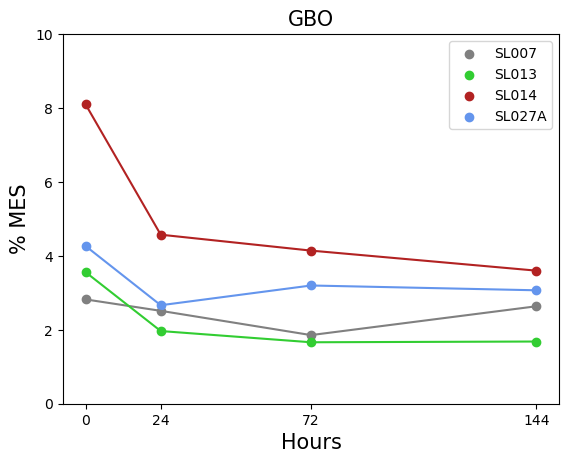

In [9]:
numb = merg.columns.astype(int)
plt.scatter(numb, merg.iloc[0],label=(merg.index[0]), color='grey')
plt.scatter(numb, merg.iloc[1],label=(merg.index[1]), color='limegreen')
plt.scatter(numb, merg.iloc[2],label=(merg.index[2]), color='firebrick')
plt.scatter(numb, merg.iloc[3],label=(merg.index[3]), color='cornflowerblue')
plt.plot(numb, merg.iloc[0], color='grey')
#plt.fill_between(numb, np.min(merged[0:3]),np.max(merged[0:3]), color='grey', alpha=0.2)
#plt.errorbar(numb, merg.iloc[0], yerr=((merg[0:1]-np.min(merged[0:3])).iloc[0], np.max(merged[0:3])-merg[0:1].iloc[0]), color='grey',capsize=8)
plt.plot(numb, merg.iloc[1], color='limegreen')
#plt.fill_between(numb,np.min(merged[3:6]),np.max(merged[3:6]), color='limegreen', alpha=0.2)
#plt.errorbar(numb, merg.iloc[1], yerr=((merg[1:2]-np.min(merged[3:6])).iloc[0], np.max(merged[3:6])-merg[1:2].iloc[0]),color='limegreen',capsize=8)
plt.plot(numb, merg.iloc[2], color='firebrick')
#plt.fill_between(numb,np.min(merged[6:9]),np.max(merged[6:9]), color='firebrick', alpha=0.2)
#plt.errorbar(numb, merg.iloc[2], yerr=((merg[2:3]-np.min(merged[6:9])).iloc[0], np.max(merged[6:9])-merg[2:3].iloc[0]), color='firebrick',capsize=8)
plt.plot(numb, merg.iloc[3], color='cornflowerblue')
#plt.fill_between(numb,np.min(merged[9:12]),np.max(merged[9:12]), color='cornflowerblue', alpha=0.2)
#plt.errorbar(numb, merg.iloc[3], yerr=((merg[3:4]-np.min(merged[9:12])).iloc[0], np.max(merged[9:12])-merg[3:4].iloc[0]), color='cornflowerblue',capsize=8)
plt.ylim(0, 10)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 10, where= (tr < 140) & (tr > 0), color='lightblue', alpha=0.2)
plt.show()

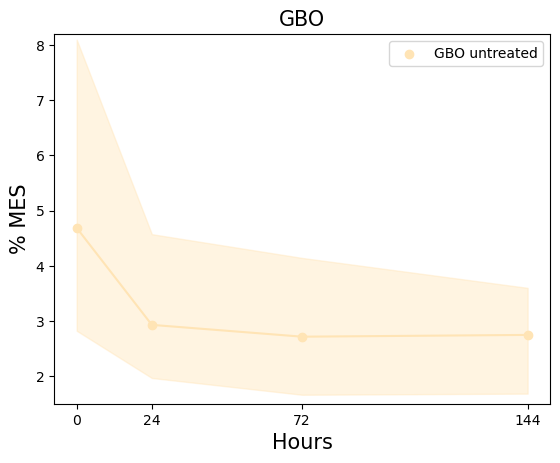

In [74]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(1.5, 8.2)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% MES', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 10, where= (tr < 140) & (tr > 0), color='lightblue', alpha=0.2)
plt.savefig("/proj/cytograph/jesper/Figures/revision/GBO_control_MES.pdf", dpi=300)

In [69]:
np.array(np.min(merg[0:3]))

array([0.8408358, 1.019334 , 1.0371574, 1.0536158], dtype=float32)

In [70]:
np.array(np.max(merg[0:3]))

array([2.1921692, 2.1973271, 2.3454032, 2.0877485], dtype=float32)

In [71]:
np.array(np.mean(merg, axis=0))

array([1.4272572, 1.591781 , 1.6139   , 1.5618477], dtype=float32)

In [35]:
#+p-h 0 vs 24 hours
mannwhitneyu(merg[0:4]['0'], merg[0:4]['24']), ttest_ind(merg[0:4]['0'], merg[0:4]['24'])

(MannwhitneyuResult(statistic=13.0, pvalue=0.2),
 Ttest_indResult(statistic=1.3467785020694685, pvalue=0.2266929687700153))

In [36]:
#+p-h 0 vs 24 hours
mannwhitneyu(merg[0:4]['0'], merg[0:4]['72']), ttest_ind(merg[0:4]['0'], merg[0:4]['72'])

(MannwhitneyuResult(statistic=13.0, pvalue=0.2),
 Ttest_indResult(statistic=1.5019552438124493, pvalue=0.18379036290446613))

In [75]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[OPC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg1 = merg.mean(axis=0)
merg

,0,24,72,144
SL007,1.608988,1.603059,1.710664,1.627846
SL013,0.798169,0.770767,0.925760,0.950594
SL014,0.487409,0.593111,0.730486,0.704284
SL027A,0.990735,0.979200,1.076399,1.096952


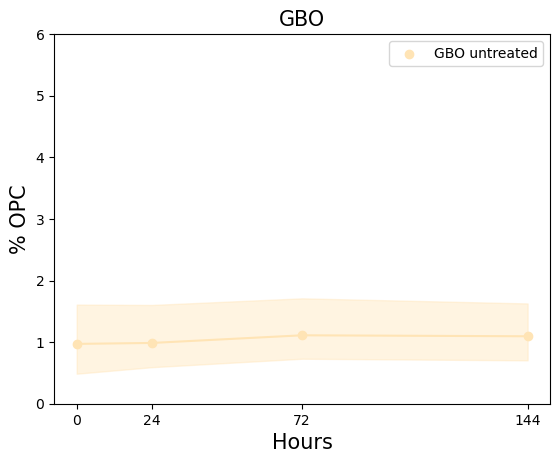

In [76]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% OPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 10, where= (tr < 140) & (tr > 0), color='lightblue', alpha=0.2)
plt.savefig("/proj/cytograph/jesper/Figures/revision/GBO_control_OPC.pdf", dpi=300)

In [83]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[NPC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg1 = merg.mean(axis=0)
merg

,0,24,72,144
SL007,2.192169,2.197327,2.345403,2.087749
SL013,1.466083,1.736872,1.774208,1.804754
SL014,0.840836,1.019334,1.037157,1.053616
SL027A,1.209941,1.413591,1.298830,1.301273


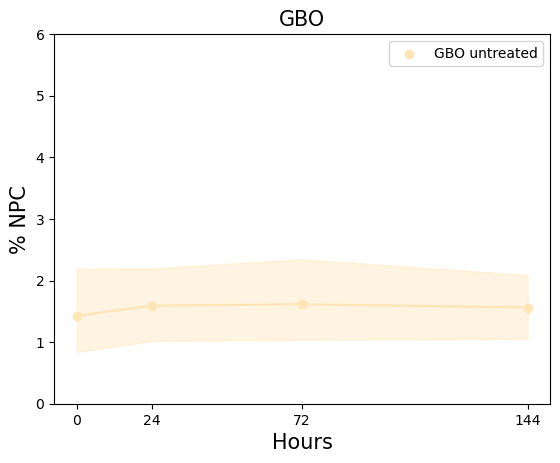

In [84]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% NPC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 10, where= (tr < 140) & (tr > 0), color='lightblue', alpha=0.2)
plt.savefig("/proj/cytograph/jesper/Figures/revision/GBO_control_NPC.pdf", dpi=300)

In [79]:
df = GBO.to_df(layer=None)
df_all = df.sum(axis=1)
MES_df = df[AC]
df_mes = MES_df.sum(axis=1)
zero = GBO[GBO.obs["Time"] == "0h"]
zero_all = df_all[zero.obs.index]
zero_mes = df_mes[zero.obs.index]
one = GBO[GBO.obs["Time"] == "24h"]
one_all = df_all[one.obs.index]
one_mes = df_mes[one.obs.index]
three = GBO[GBO.obs["Time"] == "72h"]
three_all = df_all[three.obs.index]
three_mes = df_mes[three.obs.index]
six = GBO[GBO.obs["Time"] == "144h"]
six_all = df_all[six.obs.index]
six_mes = df_mes[six.obs.index]
MES_zero = zero_mes/zero_all
MES_one = one_mes/one_all
MES_three = three_mes/three_all
MES_six = six_mes/six_all
merged = pd.concat([MES_zero, MES_one, MES_three, MES_six], axis=1)
merged = merged.rename(columns={0: '0', 1: '24', 2:'72', 3: '144'})
rename = dict(GBO.obs.Time_Sample)
merged1 = merged.rename(index=rename)
merged1 = merged1.multiply(100)
rename = dict(GBO.obs.Sample)
merg = merged.rename(index=rename)
merg = merg.mean(level=0)
merg = merg.multiply(100)
merg1 = merg.mean(axis=0)
merg

,0,24,72,144
SL007,5.253101,4.968283,4.196188,4.615681
SL013,1.131346,0.818558,1.096786,0.958497
SL014,3.556216,3.639995,4.194310,3.871093
SL027A,3.269437,3.428914,2.851513,3.218930


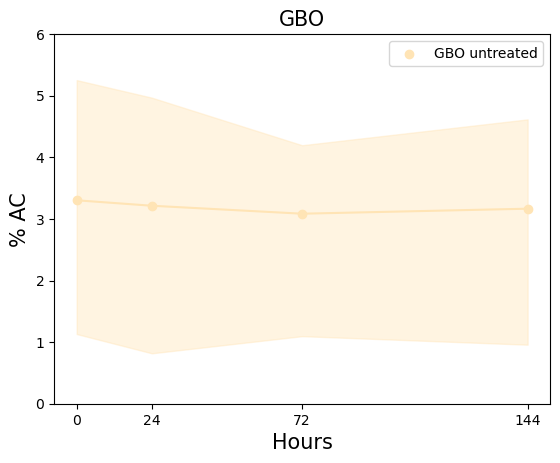

In [80]:
numb = merg1.index.astype(int)
plt.scatter(numb, merg1,label='GBO untreated', color='moccasin')
plt.plot(numb, merg1, color='moccasin')
plt.fill_between(numb, np.min(merg[0:3]),np.max(merg[0:3]), color='moccasin', alpha=0.4)
plt.ylim(0, 6)
plt.legend()
plt.xlabel('Hours', fontsize=15)
plt.ylabel('% AC', fontsize=15)
plt.title('GBO', fontsize=15)
plt.xticks(numb)
threshold1 = 0.2
threshold2 = 71
tr = numb +3
#plt.fill_between(tr, 10, where= (tr < 140) & (tr > 0), color='lightblue', alpha=0.2)
plt.savefig("/proj/cytograph/jesper/Figures/revision/GBO_control_AC.pdf", dpi=300)